In [4]:
import karateclub as kc
import matplotlib.pyplot as plt
import networkx as nx
from networkx.drawing.nx_pydot import graphviz_layout
import numpy as np
import os
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import pydot
import random
import warnings

from reeb_utils import collapse_traj, do_reeb_for_start_end, do_reeb_for_explore_node, plot_treeb
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics.cluster import adjusted_rand_score, normalized_mutual_info_score


warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None

## Load data

In [22]:
# load data into dataframe
df = pd.read_csv("data/MLINDIV_train_full.csv")

test_df = df[df["eprocs"].str.contains("Test")]

test_df["subj_mean_acc"] = test_df.groupby("Subject")["accuracy"].transform("mean")
test_df["path_mean_acc"] = test_df.groupby(["StartAt", "EndAt"])["accuracy"].transform("mean")

test_df['quartile'] = (
    pd.qcut(test_df['subj_mean_acc'], 4, labels=[1, 2, 3, 4])
)

test_df["path_mean_acc_by_Q"] = test_df.groupby(["StartAt", "EndAt", "quartile"])["accuracy"].transform("mean")

## EXPLORE DF
explore_df = df[df["eprocs"].str.contains("Explore")]

# By quartile
q_dict = {}
acc_dict = {}
for index, row in test_df[["Subject", "quartile", "subj_mean_acc"]].iterrows():
    subj, q, acc = row["Subject"], row["quartile"], row["subj_mean_acc"]
    if subj not in q_dict:
        q_dict[subj] = q
        acc_dict[subj] = acc

explore_df["quartile"] = explore_df["Subject"].map(q_dict)
explore_df["subject_mean_acc"] = explore_df["Subject"].map(acc_dict)

def compute_explore_traj(e_path):
    # need to replace V-east (V2) with Y and F-south (F3) with N
    # because they are facing and can see the object from there
    path = e_path.replace("V2", "Y2")
    path = e_path.replace("F3", "N3")
    
    nodes = path.split()
    nodes.remove("NA")
    nodes = [n[0] for n in nodes]

    return "".join(collapse_traj(nodes))

# concatenate explore rounds for now
explore_df["explore_path"] = explore_df.groupby("Subject")["e_paths"].transform(" ".join)
explore_df = explore_df.drop_duplicates(subset=["Subject"], keep="first")

explore_df["explore_traj"] = explore_df["explore_path"].apply(compute_explore_traj)
explore_df["num_nodes_visited"] = explore_df["explore_traj"].apply(len)

explore_df[["explore_traj", "quartile", "subject_mean_acc"]]

,explore_traj,quartile,subject_mean_acc
0,URQTXVXZPZXTQHGLGAGHBCICDEMOMSRUTXTUWUTXVYVXZP...,3.0,0.916667
50,RSMOMEDJKJRUWUTQRQTXVYVXZPZXTQHGLGAGHBCICDEMOM...,4.0,1.000000
100,URQTXZPZXVXTURSMEFNFEDCICBHQHGAGLGHBCDJRJKJRUR...,2.0,0.375000
110,UWURSMEFNFEDCBHGLGHGAGHQTXVYVXZPZXTUWURQHGAGLG...,3.0,0.791667
160,DJRUWUTXVYVXZPZXTQRSMEFNFEDJRQHGLGAGHQTXVXZXTU...,1.0,0.229167
...,...,...,...
4837,RJDCBHQTXVYVXTURJDEFNFEDCBHQTXVXZPZXTUWURSMEDC...,1.0,0.125000
4887,URJDCBHGAGLGHQTXZPZXVXTUWURSMEFNFEDCBHGAGHQRJK...,2.0,0.375000
4937,DJKJRQHBHGAGHQTXVYVXTQRSMOMSRJDEFNFEMSRUWUTXVX...,2.0,0.416667
4987,RJDCICDEMOMSRJKJDCBHGLGHQRUWUTXVYVXZPZXTQHGAGL...,3.0,0.854167


## Explore-treeb specific functions

In [3]:
from reeb_utils import all_traj_same

def simplify_path(path):
    nodes_visited = path.split()[:-1]
    
    simplified = ""
    for i in range(len(nodes_visited)-1):
        rt = {1:2, 2:3, 3:4, 4:1}
        lt = {2:1, 1:4, 4:3, 3:2}

        curr_node, next_node = nodes_visited[i], nodes_visited[i+1]
        if curr_node[0] != next_node[0]:
            # forward press
            simplified += "F"
        elif rt[int(curr_node[1])] == int(next_node[1]):
            # right turn
            simplified += "R"
        elif lt[int(curr_node[1])] == int(next_node[1]):
            # left turn
            simplified += "L"
        else:
            # print(curr_node, next_node)
            simplified += "R"
            ## N3 N1 spin
            # print("FUCK ME")
        
    return simplified

def generate_reeb_tree(start_i, start_node, trajs, which_trajs, G, visited, SUCCESS="", DEBUG=False):
    """Generates Reeb tree.

    TODO talk about what this means

    Parameters
    ----------
    start_i : TODO,
        TODO
    start_node : TODO,
        TODO
    trajs : list,
        Shape = [n_trajs, various]
        List of all trajectories over which to compute the Reeb tree.
    G : nx.Graph,
        Reeb tree to mutate in place as graph is construted.
    visited : TODO,
        TODO
    DEBUG : boolean,
        If True print more things.

    Returns
    -------
    None
    """
    if DEBUG: print(f"DO REEB, {start_i}, {start_node}, {which_trajs}")
    times_before = visited.get(start_node, 0) 
    visited[start_node] = times_before
    to_add = start_node + "_" + str(times_before)

    max_traj_len = max([len(trajs[t]) for t in which_trajs])

    ## BASE CASE 1: SINGLETON ##
    ## BASE CASE 2: ALL THE SAME ##
    if len(which_trajs) == 1 or all_traj_same(trajs, which_trajs, max_traj_len):
        end_node = trajs[which_trajs[0]][-1]
        times_before = visited.get(end_node, -1) + 1
        visited[end_node] = times_before
        
        end_node +=  "_" + str(times_before)
        if DEBUG: print(f"BASE CASE: {which_trajs}, last: {end_node}")

        color = "green" if SUCCESS in end_node else "yellow"
        G.add_node(end_node, color=color, end=True)
        G.add_edge(to_add, end_node, weight=len(which_trajs))

        return
    

    ## RECURSIVE STEP ##
    if DEBUG: print(f"FOR LOOP, {start_i}, {which_trajs}")
    for step in range(start_i, max_traj_len):
        
        new_gn = {}
        for i in which_trajs:
            traj = trajs[i]

            ## STOPPING CONDITION FOR THIS ONE GUY ##
            if step >= len(traj): 
                new_gn["DONE"] = new_gn.get("DONE", []).copy() + [i]
            else:
                new_node = traj[step]     
                new_gn[new_node] = new_gn.get(new_node, []).copy() + [i]

        if DEBUG: print("NEW_GN", new_gn)
        # decide whether we need a reeb node
        
        # people went different ways!!
        if len(new_gn.keys()) > 1:
            times_before = visited.get(start_node, 0)
            sn = start_node + "_" + str(times_before)
            
            

            if DEBUG: print("VISITED", visited)
            
            for k, v in new_gn.items():
                if DEBUG: print("RECURSE")

                # the thing happened at the node before this! all the paths in this fn are at the same point there so it doesnt mattter
                old_one = k#trajs[which_trajs[0]][step-1]
                times_before = visited.get(old_one, -1) + 1
                visited[old_one] = times_before

                

                on = k + "_" + str(times_before)
                G.add_node(on, color="blue", end=False)
                if DEBUG: print(f"ADDING NEW BLUE NODE {on}")
                
                G.add_edge(sn, on, weight=len(which_trajs))
                if DEBUG: print(f"ADDING NEW EDGE from {sn} to {on}, weight is {len(which_trajs)}")

                if DEBUG and k == "DONE":
                    print("*@#)$*$#()*(#@($")
                    print(new_gn)
                    
                generate_reeb_tree(step+1, old_one, trajs,  v, G, visited, SUCCESS=SUCCESS, DEBUG=DEBUG)

            return

In [16]:
def extract_tree_features(graph, root):
    # Number of Nodes
    num_nodes = graph.number_of_nodes()
    
    # Number of Edges
    num_edges = graph.number_of_edges()
    
    # Tree Depth (Height)
    def tree_depth(graph, root):
        depths = nx.single_source_shortest_path_length(graph, root)
        return max(depths.values())
    
    depth = tree_depth(graph, root)
    
    # Average Node Degree
    avg_degree = np.mean([degree for node, degree in graph.degree()])
    
    # Diameter
    diameter = nx.diameter(graph)
    
    # Number of Leaves
    num_leaves = sum(1 for node in graph.nodes() if graph.degree(node) == 1)
    
    # Average Path Length
    avg_path_length = nx.average_shortest_path_length(graph)
    
    # Branching Factor
    branching_factors = [len(list(graph.neighbors(node))) for node in graph.nodes()]
    avg_branching_factor = np.mean(branching_factors)
    
    # Clustering Coefficient
    clustering_coeffs = nx.clustering(graph)
    avg_clustering_coeff = np.mean(list(clustering_coeffs.values()))
    
    # Put all features in a list
    features = [
        num_nodes,
        num_edges,
        depth,
        avg_degree,
        diameter,
        num_leaves,
        avg_path_length,
        avg_branching_factor,
        avg_clustering_coeff
    ]
    
    return features

## Create explore treebs

In [24]:
etreebs = []
qs = []
accs = []
for i, row in explore_df.iterrows():
    path = row["e_paths"]
    simplified_path = simplify_path(path)
    
    trajs = []
    salient_node = "F"
    for i in range(len(simplified_path)):
        if simplified_path[i] == salient_node:# if i%5 == 0:
            trajs.append(simplified_path[i: i+5])
    
    trajs = trajs[:25]
    
    G = nx.Graph()
    G.add_node(salient_node + "_0", color="red", end=False)
    
    if len(trajs) != 0:
        visited = {}
        generate_reeb_tree(0, salient_node, trajs, [i for i in range(len(trajs))], G, visited, SUCCESS="IMPOSSIBLE", DEBUG=False)
    
    new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') #first_label is the starting integer label, in this case zero

    etreebs.append(new_G.copy())

    if row["quartile"]:
        qs.append(row["quartile"])
    else:
        qs.append(1)

    accs.append(row["subject_mean_acc"])
    # print(G.edges)
    # plot_treeb(G)

## Graph embeddings & clustering

ARI: 0.03 (random would be: 0.01)
NMI: 0.07 (random would be: 0.03)
[0.27560866 0.08338272]
[[0.6153642  0.05457509 0.05865192 0.34189287 0.17550762 0.34990937
  0.3367377  0.09585702 0.01583483 0.13553645 0.06352534 0.05891462
  0.12064002 0.24473493 0.11216013 0.33021328]
 [0.01025003 0.01871424 0.15842041 0.01464394 0.24603625 0.2332339
  0.3133365  0.3358214  0.2246211  0.38830894 0.41539702 0.31382927
  0.32119265 0.21121861 0.02669583 0.16605003]]


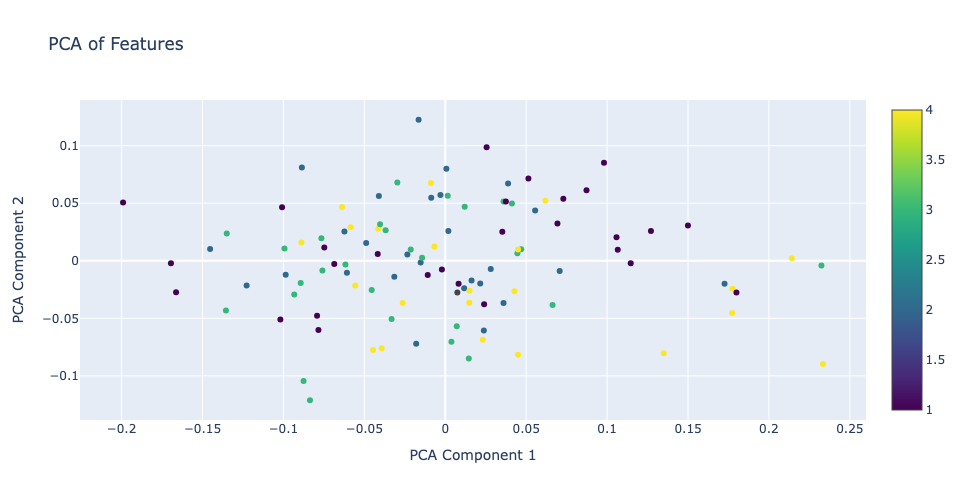

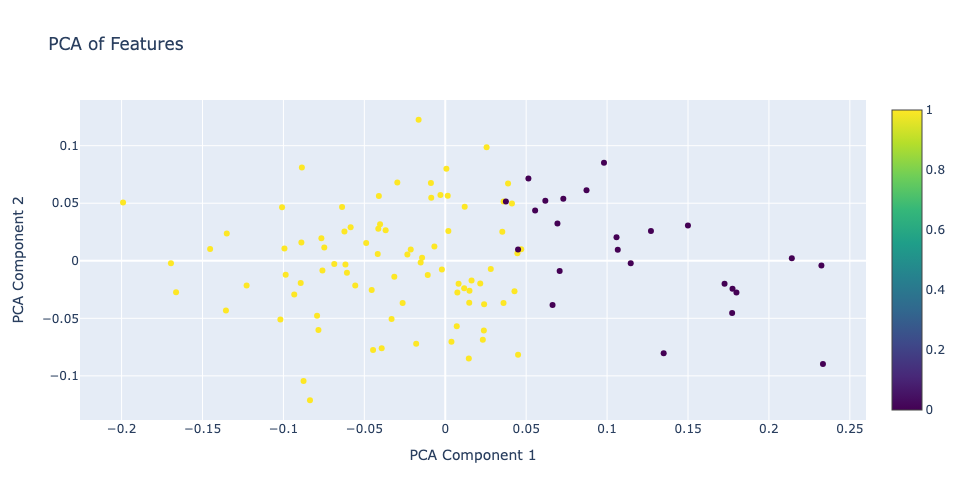

In [42]:
use_embeddings = True

features = []
people = []
for i, graph in enumerate(etreebs):
    features.append(extract_tree_features(graph, 0))
    people.append(i)
features = np.array(features)

if use_embeddings:
    explore_model = kc.Graph2Vec(dimensions=16)
    explore_model.fit(etreebs)
    
    features = explore_model.get_embedding()
    

# Specify the number of clusters
num_clusters = 2

# Perform K-means clustering
kmeans = KMeans(n_clusters=num_clusters, random_state=0)
kmeans.fit(features)

# Get the cluster assignments
labels = kmeans.labels_

## CALCULATE ACCURACY OF CLUSTERING!!!
true_labels = []
for l in qs:
    if not pd.isna(l):
        true_labels.append(l)
    else:
        true_labels.append(0)
baseline = [random.randint(0, 4) for _ in range(len(true_labels))]

print(f"ARI: {adjusted_rand_score(true_labels, labels):.2f} (random would be: {adjusted_rand_score(baseline, labels):.2f})")
print(f"NMI: {normalized_mutual_info_score(true_labels, labels):.2f} (random would be: {normalized_mutual_info_score(baseline, labels):.2f})")

# Reduce dimensionality to 2D for visualization
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(features)

# to know if we can trust our eyes
# if it is very low then the higher dimension info matters a lot & we can't see
# above 0.7 is good!
print(pca.explained_variance_ratio_)
print(abs(pca.components_))

# Plot the clusters with Plotly to have interactive
fig = go.Figure()

# Scatter plot for 'Trees by Quartile'
fig.add_trace(go.Scatter(
    x=reduced_features[:, 0],
    y=reduced_features[:, 1],
    mode='markers',
    text=people,
    marker=dict(color=qs, colorscale='Viridis', showscale=True),
    name='Trees by Quartile'
))

# Update layout
fig.update_layout(
    title="PCA of Features",
    xaxis_title="PCA Component 1",
    yaxis_title="PCA Component 2",
    legend_title="Clusters",
    height=500,
    width=500
)

fig.show()

# Plot the clusters with Plotly to have interactive
fig2 = go.Figure()

# Scatter plot for 'K-means Clustering of Graphs'
fig2.add_trace(go.Scatter(
    x=reduced_features[:, 0],
    y=reduced_features[:, 1],
    mode='markers',
    marker=dict(color=labels, colorscale='Viridis', showscale=True),
    name='K-means Clustering of Graphs'
))

# Update layout
fig2.update_layout(
    title="PCA of Features",
    xaxis_title="PCA Component 1",
    yaxis_title="PCA Component 2",
    legend_title="Clusters",
    height=500,
    width=500
)

fig2.show()

In [43]:
# print(labels)
# print(accs)

grouped_accs = {group: [] for group in set(labels)}
for group, acc in zip(labels, accs):
    if not pd.isna(acc):
        grouped_accs[group].append(acc)

for group in grouped_accs:
    print(group)
    # print(grouped_accs[group])
    print(np.mean(grouped_accs[group]))
    print(np.var(grouped_accs[group]))

0
0.4718171296296296
0.1346991511006087
1
0.6046033319455562
0.09346251604275568
